# Entrenamiento completo del modelo de vulnerabilidades

## 1. Configuracion

In [1]:
from pathlib import Path

import json
import os
import shutil
import subprocess
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

MODEL_DIR = PROJECT_ROOT / 'models'
REPORT_DIR = PROJECT_ROOT / 'reports'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.25
VALIDATION_SIZE = 0.20
SYNTHETIC_SOURCES = {'owasp2025'}
FEATURE_COLUMNS = ['raw_code', 'language', 'source', 'code_length', 'line_count']
THRESHOLD_METRIC = 'accuracy'
MIN_ACCURACY_TARGET = 0.80
USE_AST_FEATURES = False
USE_SECURITY_PATTERN_FEATURES = False


def has_cuda() -> bool:
    return shutil.which('nvidia-smi') is not None and subprocess.run(['nvidia-smi'], capture_output=True).returncode == 0

CUDA_AVAILABLE = has_cuda()
print('Proyecto:', PROJECT_ROOT)
print('CUDA disponible:', CUDA_AVAILABLE)

MAX_RECORDS_PER_SOURCE = None
if os.getenv('NOTEBOOK_MAX_RECORDS_PER_SOURCE'):
    value = os.environ['NOTEBOOK_MAX_RECORDS_PER_SOURCE'].strip().lower()
    MAX_RECORDS_PER_SOURCE = None if value in {'none', 'all', '0'} else int(value)
else:
    MAX_RECORDS_PER_SOURCE = None
INCLUDE_CVEFIXES_ZIP = True
OUTPUT_DATASET_NAME = 'combined_clean_vulnerability_dataset.csv'
MODEL_FILENAME = 'vulnerability_model.joblib'
VECTORIZER_FILENAME = 'vectorizer.joblib'
METRICS_FILENAME = 'metrics.json'
METADATA_FILENAME = 'training_metadata.json'
print('MAX_RECORDS_PER_SOURCE:', MAX_RECORDS_PER_SOURCE)
print('USE_AST_FEATURES:', USE_AST_FEATURES)
print('USE_SECURITY_PATTERN_FEATURES:', USE_SECURITY_PATTERN_FEATURES)

Proyecto: C:\Users\gamur\Documents\ESPE VII SI 2026\Desarrollo Seguro\U2\p\ProyectoSegundoParcialSWSeguro
CUDA disponible: True
MAX_RECORDS_PER_SOURCE: None
USE_AST_FEATURES: False
USE_SECURITY_PATTERN_FEATURES: False


## 2. Limpieza y unificacion de datasets

In [2]:
import pandas as pd
from app.infrastructure.repositories.dataset_cleaning import build_clean_training_frame

build_result = build_clean_training_frame(
    PROJECT_ROOT,
    max_records_per_source=MAX_RECORDS_PER_SOURCE,
    include_cvefixes=INCLUDE_CVEFIXES_ZIP,
)
df = build_result.frame.copy()
profile = build_result.profile

clean_csv = PROCESSED_DIR / OUTPUT_DATASET_NAME
df.to_csv(clean_csv, index=False)
print('Dataset limpio guardado:', clean_csv)
print('Registros finales:', len(df))
print('MAX_RECORDS_PER_SOURCE:', MAX_RECORDS_PER_SOURCE)
display(df.groupby(['source', 'is_vulnerable']).size().unstack(fill_value=0))
display(df.groupby(['language', 'is_vulnerable']).size().unstack(fill_value=0))

Dataset limpio guardado: C:\Users\gamur\Documents\ESPE VII SI 2026\Desarrollo Seguro\U2\p\ProyectoSegundoParcialSWSeguro\data\processed\combined_clean_vulnerability_dataset.csv
Registros finales: 454230
MAX_RECORDS_PER_SOURCE: None


is_vulnerable,0,1
source,,
codexglue,14827,12420
d2a,2444,2792
megavul_c_cpp,339426,16751
megavul_java,40501,2272
owasp2025,128,288
reveal,20313,2068


is_vulnerable,0,1
language,,
c,268592,13337
cpp,96033,16814
java,40501,2272
javascript,33,18
python,2,0
unknown,12478,4150


## 3. Split realista por grupos

In [3]:
from sklearn.model_selection import GroupShuffleSplit

real_df = df[~df['source'].isin(SYNTHETIC_SOURCES)].copy()
synthetic_df = df[df['source'].isin(SYNTHETIC_SOURCES)].copy()
if real_df['is_vulnerable'].nunique() < 2:
    raise RuntimeError('El holdout real no tiene ambas clases. Revisa los datasets cargados.')

real_groups = real_df['group_id'].where(real_df['group_id'].astype(str).str.len() > 0, real_df['code_hash'])
test_splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_real_idx, test_idx = next(test_splitter.split(real_df, real_df['is_vulnerable'], groups=real_groups))

train_real_df = real_df.iloc[train_real_idx].copy()
test_df = real_df.iloc[test_idx].copy()
train_real_df = train_real_df[~train_real_df['code_hash'].isin(set(test_df['code_hash']))].copy()

validation_groups = train_real_df['group_id'].where(train_real_df['group_id'].astype(str).str.len() > 0, train_real_df['code_hash'])
validation_splitter = GroupShuffleSplit(n_splits=1, test_size=VALIDATION_SIZE, random_state=RANDOM_STATE)
fit_idx, valid_idx = next(validation_splitter.split(train_real_df, train_real_df['is_vulnerable'], groups=validation_groups))
fit_df = train_real_df.iloc[fit_idx].copy()
valid_df = train_real_df.iloc[valid_idx].copy()

X_fit = fit_df[FEATURE_COLUMNS]
y_fit = fit_df['is_vulnerable'].astype(int)
X_valid = valid_df[FEATURE_COLUMNS]
y_valid = valid_df['is_vulnerable'].astype(int)
X_train = train_real_df[FEATURE_COLUMNS]
y_train = train_real_df['is_vulnerable'].astype(int)
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df['is_vulnerable'].astype(int)

majority_label = int(y_test.value_counts().idxmax())
baseline_accuracy = float((y_test == majority_label).mean())

print('Fit real:', len(fit_df), y_fit.value_counts().to_dict())
print('Validacion real:', len(valid_df), y_valid.value_counts().to_dict())
print('Train real completo:', len(train_real_df), y_train.value_counts().to_dict())
print('Test real:', len(test_df), y_test.value_counts().to_dict())
print('Baseline clase mayoritaria en test:', round(baseline_accuracy, 4), 'clase:', majority_label)
display(train_real_df.groupby(['source', 'is_vulnerable']).size().unstack(fill_value=0))
display(test_df.groupby(['source', 'is_vulnerable']).size().unstack(fill_value=0))
display(test_df.groupby(['language', 'is_vulnerable']).size().unstack(fill_value=0))

Fit real: 272522 {0: 250717, 1: 21805}
Validacion real: 67842 {0: 62355, 1: 5487}
Train real completo: 340364 {0: 313072, 1: 27292}
Test real: 113450 {0: 104439, 1: 9011}
Baseline clase mayoritaria en test: 0.9206 clase: 0


is_vulnerable,0,1
source,,
codexglue,10930,9419
d2a,1819,2094
megavul_c_cpp,254446,12502
megavul_java,30484,1709
reveal,15393,1568


is_vulnerable,0,1
source,,
codexglue,3897,3001
d2a,625,698
megavul_c_cpp,84980,4249
megavul_java,10017,563
reveal,4920,500


is_vulnerable,0,1
language,,
c,67259,3392
cpp,24412,4240
java,10017,563
javascript,12,4
unknown,2739,812


## 4. Pipeline de features y modelo

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def build_model_pipeline(labels: pd.Series) -> tuple[Pipeline, str]:
    feature_blocks = [
        ('word_hash', HashingVectorizer(n_features=2**18, ngram_range=(1, 2), alternate_sign=False, norm='l2'), 'raw_code'),
        ('category', OneHotEncoder(handle_unknown='ignore', sparse_output=True), ['language', 'source']),
        ('numeric', StandardScaler(with_mean=False), ['code_length', 'line_count']),
    ]
    if USE_SECURITY_PATTERN_FEATURES:
        from app.infrastructure.ml.code_feature_extractor import SecurityPatternFeatureExtractor
        feature_blocks.insert(1, ('security', SecurityPatternFeatureExtractor(), 'raw_code'))
    if USE_AST_FEATURES:
        from app.infrastructure.ml.ast_extractor import ASTFeatureExtractor
        feature_blocks.insert(1, ('ast', ASTFeatureExtractor(), 'raw_code'))

    features = ColumnTransformer(feature_blocks)

    from sklearn.linear_model import SGDClassifier
    classifier = SGDClassifier(
        loss='log_loss',
        penalty='elasticnet',
        alpha=0.0001,
        l1_ratio=0.15,
        class_weight='balanced',
        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model_name = 'SGD log-loss all-records CPU'
    return Pipeline([('features', features), ('clf', classifier)]), model_name

threshold_model, model_name = build_model_pipeline(y_fit)
threshold_model.fit(X_fit, y_fit)
print('Modelo para calibrar umbral:', model_name)


Modelo para calibrar umbral: SGD log-loss all-records CPU


## 5. Metricas, umbral y graficas

{'model': 'SGD log-loss all-records CPU', 'cuda_available': True, 'max_records_per_source': None, 'evaluation_strategy': 'real_sources_group_holdout_with_validation_threshold', 'synthetic_sources_excluded_from_eval': ['owasp2025'], 'threshold_metric': 'accuracy', 'decision_threshold': 0.87, 'validation_threshold_metrics': {'accuracy': 0.9203, 'precision': 0.5096, 'recall': 0.3763, 'f1': 0.433}, 'total_clean_records': 454230, 'fit_records': 272522, 'validation_records': 67842, 'train_records': 340364, 'test_records': 113450, 'baseline_majority_accuracy': 0.9206, 'accuracy': 0.9161, 'min_accuracy_target': 0.8, 'meets_accuracy_target': True, 'precision': 0.4663, 'recall': 0.391, 'f1_score': 0.4253, 'roc_auc': 0.8397, 'confusion_matrix': [[100406, 4033], [5488, 3523]], 'classification_report': {'0': {'precision': 0.9481745896840237, 'recall': 0.9613841572592614, 'f1-score': 0.9547336842055217, 'support': 104439.0}, '1': {'precision': 0.4662519851773425, 'recall': 0.39096659638219955, 'f1-s

,precision,recall,f1-score,support
0,0.948175,0.961384,0.954734,104439.000000
1,0.466252,0.390967,0.425303,9011.000000
accuracy,0.916078,0.916078,0.916078,0.916078
macro avg,0.707213,0.676175,0.690018,113450.000000
weighted avg,0.909897,0.916078,0.912683,113450.000000


,language,records,accuracy,precision,recall,f1
0,c,70651.0,0.951664,0.487432,0.131486,0.207105
2,java,10580.0,0.946314,0.456140,0.046181,0.083871
1,cpp,28652.0,0.840500,0.469769,0.604717,0.528769
4,unknown,3551.0,0.728809,0.432529,0.596059,0.501295
3,javascript,16.0,0.687500,0.428571,0.750000,0.545455


,source,records,accuracy,precision,recall,f1
2,megavul_c_cpp,89229.0,0.951977,0.483636,0.125206,0.198916
3,megavul_java,10580.0,0.946314,0.456140,0.046181,0.083871
4,reveal,5420.0,0.885240,0.280576,0.156000,0.200514
1,d2a,1323.0,0.515495,0.524380,0.878223,0.656668
0,codexglue,6898.0,0.506379,0.459208,0.757747,0.571860


,threshold,accuracy,precision,recall,f1
82,0.87,0.920271,0.509625,0.376344,0.432959
81,0.86,0.920241,0.508887,0.396574,0.445765
84,0.89,0.920123,0.509770,0.323310,0.395673
83,0.88,0.920123,0.509014,0.349918,0.414732
80,0.85,0.920020,0.506816,0.413341,0.455330
85,0.90,0.919858,0.507942,0.291416,0.370353
79,0.84,0.919814,0.505051,0.428285,0.463511
78,0.83,0.919755,0.504482,0.441042,0.470634
77,0.82,0.919475,0.502416,0.454711,0.477375
86,0.91,0.919460,0.504132,0.255695,0.339299


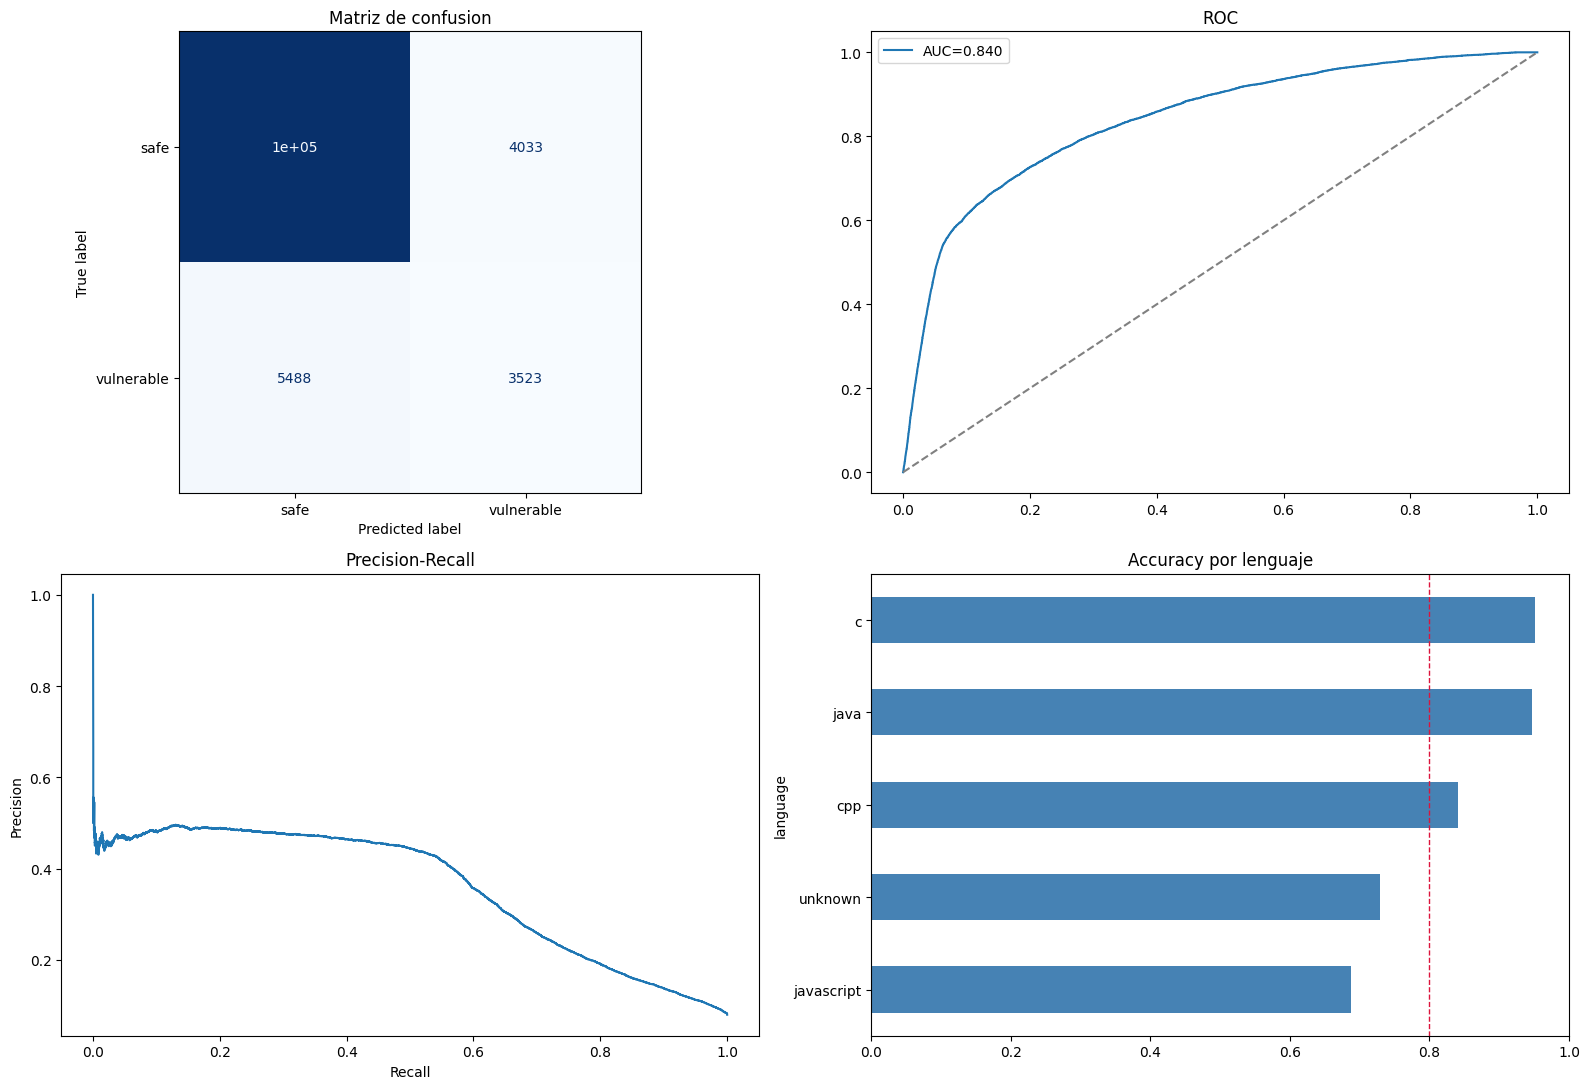

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)


def threshold_table(y_true: pd.Series, probabilities: np.ndarray) -> pd.DataFrame:
    rows = []
    for threshold in np.linspace(0.05, 0.95, 91):
        predictions_at_threshold = (probabilities >= threshold).astype(int)
        rows.append({
            'threshold': float(threshold),
            'accuracy': float(accuracy_score(y_true, predictions_at_threshold)),
            'precision': float(precision_score(y_true, predictions_at_threshold, zero_division=0)),
            'recall': float(recall_score(y_true, predictions_at_threshold, zero_division=0)),
            'f1': float(f1_score(y_true, predictions_at_threshold, zero_division=0)),
        })
    return pd.DataFrame(rows)

valid_probabilities = threshold_model.predict_proba(X_valid)[:, 1]
threshold_frame = threshold_table(y_valid, valid_probabilities)
best_row = threshold_frame.sort_values([THRESHOLD_METRIC, 'f1', 'precision'], ascending=False).iloc[0]
BEST_THRESHOLD = float(best_row['threshold'])

pipeline, model_name = build_model_pipeline(y_train)
pipeline.fit(X_train, y_train)
probabilities = pipeline.predict_proba(X_test)[:, 1]
predictions = (probabilities >= BEST_THRESHOLD).astype(int)

eval_df = test_df[['source', 'language']].copy()
eval_df['y_true'] = y_test.to_numpy()
eval_df['y_pred'] = predictions
eval_df['probability'] = probabilities

def grouped_metrics(group: pd.DataFrame) -> pd.Series:
    return pd.Series({
        'records': int(len(group)),
        'accuracy': accuracy_score(group['y_true'], group['y_pred']),
        'precision': precision_score(group['y_true'], group['y_pred'], zero_division=0),
        'recall': recall_score(group['y_true'], group['y_pred'], zero_division=0),
        'f1': f1_score(group['y_true'], group['y_pred'], zero_division=0),
    })

language_metrics_df = eval_df.groupby('language').apply(grouped_metrics, include_groups=False).reset_index()
source_metrics_df = eval_df.groupby('source').apply(grouped_metrics, include_groups=False).reset_index()

metrics = {
    'model': model_name,
    'cuda_available': CUDA_AVAILABLE,
    'max_records_per_source': MAX_RECORDS_PER_SOURCE,
    'evaluation_strategy': 'real_sources_group_holdout_with_validation_threshold',
    'synthetic_sources_excluded_from_eval': sorted(SYNTHETIC_SOURCES),
    'threshold_metric': THRESHOLD_METRIC,
    'decision_threshold': round(BEST_THRESHOLD, 4),
    'validation_threshold_metrics': {key: round(float(best_row[key]), 4) for key in ['accuracy', 'precision', 'recall', 'f1']},
    'total_clean_records': int(len(df)),
    'fit_records': int(len(fit_df)),
    'validation_records': int(len(valid_df)),
    'train_records': int(len(train_real_df)),
    'test_records': int(len(test_df)),
    'baseline_majority_accuracy': round(baseline_accuracy, 4),
    'accuracy': round(float(accuracy_score(y_test, predictions)), 4),
    'min_accuracy_target': MIN_ACCURACY_TARGET,
    'meets_accuracy_target': bool(accuracy_score(y_test, predictions) >= MIN_ACCURACY_TARGET),
    'precision': round(float(precision_score(y_test, predictions, zero_division=0)), 4),
    'recall': round(float(recall_score(y_test, predictions, zero_division=0)), 4),
    'f1_score': round(float(f1_score(y_test, predictions, zero_division=0)), 4),
    'roc_auc': round(float(roc_auc_score(y_test, probabilities)), 4),
    'confusion_matrix': confusion_matrix(y_test, predictions).tolist(),
    'classification_report': classification_report(y_test, predictions, output_dict=True, zero_division=0),
    'language_metrics': language_metrics_df.round(4).to_dict(orient='records'),
    'source_metrics': source_metrics_df.round(4).to_dict(orient='records'),
}

print(metrics)
display(pd.DataFrame(metrics['classification_report']).transpose())
display(language_metrics_df.sort_values('accuracy', ascending=False))
display(source_metrics_df.sort_values('accuracy', ascending=False))
display(threshold_frame.sort_values(THRESHOLD_METRIC, ascending=False).head(10))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.ravel()
ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=['safe', 'vulnerable'], cmap='Blues', colorbar=False, ax=axes[0])
axes[0].set_title('Matriz de confusion')

fpr, tpr, _ = roc_curve(y_test, probabilities)
axes[1].plot(fpr, tpr, label=f"AUC={metrics['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('ROC')
axes[1].legend()

precisions, recalls, _ = precision_recall_curve(y_test, probabilities)
axes[2].plot(recalls, precisions)
axes[2].set_title('Precision-Recall')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

language_metrics_df.sort_values('accuracy').plot.barh(x='language', y='accuracy', ax=axes[3], legend=False, color='steelblue')
axes[3].axvline(MIN_ACCURACY_TARGET, color='crimson', linestyle='--', linewidth=1)
axes[3].set_title('Accuracy por lenguaje')
axes[3].set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 6. Guardado de artefactos

In [6]:
import joblib

final_train_df = pd.concat([train_real_df, synthetic_df], ignore_index=True)
final_train_df = final_train_df.drop_duplicates(subset=['code_hash']).reset_index(drop=True)
final_X = final_train_df[FEATURE_COLUMNS]
final_y = final_train_df['is_vulnerable'].astype(int)
pipeline.fit(final_X, final_y)

model_path = MODEL_DIR / MODEL_FILENAME
vectorizer_path = MODEL_DIR / VECTORIZER_FILENAME
metrics_path = REPORT_DIR / METRICS_FILENAME
metadata_path = REPORT_DIR / METADATA_FILENAME

joblib.dump(pipeline, model_path)
joblib.dump(pipeline.named_steps['features'], vectorizer_path)
metrics_path.write_text(json.dumps(metrics, indent=2, default=str), encoding='utf-8')
metadata_path.write_text(json.dumps({
    'profile': profile,
    'config': {
        'max_records_per_source': MAX_RECORDS_PER_SOURCE,
        'include_cvefixes_zip': INCLUDE_CVEFIXES_ZIP,
        'synthetic_sources_excluded_from_eval': sorted(SYNTHETIC_SOURCES),
        'feature_columns': FEATURE_COLUMNS,
        'use_ast_features': USE_AST_FEATURES,
        'use_security_pattern_features': USE_SECURITY_PATTERN_FEATURES,
        'threshold_metric': THRESHOLD_METRIC,
        'decision_threshold': BEST_THRESHOLD,
        'final_training_records': int(len(final_train_df)),
        'final_training_label_counts': final_y.value_counts().to_dict(),
        'final_training_source_counts': final_train_df['source'].value_counts().to_dict(),
        'final_training_language_counts': final_train_df['language'].value_counts().to_dict(),
        'random_state': RANDOM_STATE,
        'test_size': TEST_SIZE,
        'validation_size': VALIDATION_SIZE,
    },
}, indent=2, default=str), encoding='utf-8')

print('Modelo:', model_path)
print('Feature transformer:', vectorizer_path)
print('Metricas:', metrics_path)
print('Metadata:', metadata_path)

Modelo: C:\Users\gamur\Documents\ESPE VII SI 2026\Desarrollo Seguro\U2\p\ProyectoSegundoParcialSWSeguro\models\vulnerability_model.joblib
Feature transformer: C:\Users\gamur\Documents\ESPE VII SI 2026\Desarrollo Seguro\U2\p\ProyectoSegundoParcialSWSeguro\models\vectorizer.joblib
Metricas: C:\Users\gamur\Documents\ESPE VII SI 2026\Desarrollo Seguro\U2\p\ProyectoSegundoParcialSWSeguro\reports\metrics.json
Metadata: C:\Users\gamur\Documents\ESPE VII SI 2026\Desarrollo Seguro\U2\p\ProyectoSegundoParcialSWSeguro\reports\training_metadata.json


## 7. Prueba local del artefacto

In [7]:
loaded_pipeline = joblib.load(model_path)
for sample in ['examples/safe_sample.cpp', 'examples/vulnerable_sample.cpp', 'examples/sql_injection_sample.cpp']:
    path = PROJECT_ROOT / sample
    if not path.exists():
        continue
    code = path.read_text(encoding='utf-8')
    sample_features = pd.DataFrame([{
        'raw_code': code,
        'language': 'cpp',
        'source': 'manual',
        'code_length': len(code),
        'line_count': len([line for line in code.splitlines() if line.strip()]),
    }])
    probability = float(loaded_pipeline.predict_proba(sample_features)[0][1])
    print(sample, {'is_vulnerable': probability >= BEST_THRESHOLD, 'probability': round(probability, 4), 'threshold': round(BEST_THRESHOLD, 4)})

examples/safe_sample.cpp {'is_vulnerable': False, 'probability': 0.6922, 'threshold': 0.87}
examples/vulnerable_sample.cpp {'is_vulnerable': False, 'probability': 0.8305, 'threshold': 0.87}
examples/sql_injection_sample.cpp {'is_vulnerable': False, 'probability': 0.7362, 'threshold': 0.87}
